In [1]:
from getdist import loadMCSamples
import getdist.plots as plots
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from pathlib import Path
from collections import defaultdict

In [2]:
# ---------------------------------------------------------
# 1. Matplotlib Global Settings (The "Fake LaTeX" Setup)
# ---------------------------------------------------------
# Disable external LaTeX to avoid installation errors
plt.rcParams['text.usetex'] = False 

# Use Matplotlib's internal Computer Modern math text
plt.rcParams['mathtext.fontset'] = 'cm' 

# Set standard text to a serif font that looks academic
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['STIXGeneral', 'Times New Roman', 'DejaVu Serif']

# ---------------------------------------------------------
# 2. GetDist Specific Plot Settings
# ---------------------------------------------------------
# Initialize a settings object to control GetDist directly
plot_settings = plots.GetDistPlotSettings()

# Adjust Font Sizes
plot_settings.axes_fontsize = 12     # Tick numbers
plot_settings.lab_fontsize = 14      # Axis labels (x, y)
plot_settings.legend_fontsize = 12   # Legend text

# Visual Tweaks for Publications
plot_settings.linewidth = 1.5              # Slightly thicker lines
plot_settings.linewidth_contour = 1.5      # Thicker contour lines
plot_settings.tick_prune = None            # Set to 'lower' if tick marks overlap
plot_settings.figure_legend_frame = False  # Removes the box around the legend
plot_settings.alpha_filled_add = 0.85      # Adjust transparency of filled contours


In [3]:
chain_dir = Path(r'/home/theppawan/class_monte/cobaya/cobaya-run/')
chain_prefixes = [p.with_suffix('') for p in chain_dir.rglob('*.checkpoint')]

models = {}
models_best_fit = {}
extract_model = defaultdict(list)

for prefix_path in chain_prefixes:
    model_name = prefix_path.name

    theory, dataset = model_name.split("_", 1)
    extract_model[theory].append(dataset)

    print(f'Loading {model_name}...')
    try:
        models[model_name] = loadMCSamples(str(prefix_path)+ ".post.add_sigma8", settings={'ignore_rows': 0.3})
        models_best_fit[model_name] = models[model_name].getParamBestFitDict(best_sample=True)
    except Exception as e:
        print(f"Warning: Could not load {model_name}. Error: {e}")

Loading Lcdm_DESI+BBN...
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN/Lcdm_DESI+BBN.post.add_sigma8.1.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN/Lcdm_DESI+BBN.post.add_sigma8.2.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN/Lcdm_DESI+BBN.post.add_sigma8.3.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN/Lcdm_DESI+BBN.post.add_sigma8.4.txt
Removed 0.3 as burn in
Loading Lcdm_DESI+BBN+SNIa...
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+SNIa/Lcdm_DESI+BBN+SNIa.post.add_sigma8.1.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+SNIa/Lcdm_DESI+BBN+SNIa.post.add_sigma8.2.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+SNIa/Lcdm_DESI+BBN+SNIa.post.add_sigma8.3.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+SNIa/Lcdm_DESI+BBN+SNIa.post.add_sigma8.4.txt
Removed 0.

Loading Lcdm_DESI+BBN+CMB_Dist...
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+CMB_Dist/Lcdm_DESI+BBN+CMB_Dist.post.add_sigma8.1.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+CMB_Dist/Lcdm_DESI+BBN+CMB_Dist.post.add_sigma8.2.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+CMB_Dist/Lcdm_DESI+BBN+CMB_Dist.post.add_sigma8.3.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+CMB_Dist/Lcdm_DESI+BBN+CMB_Dist.post.add_sigma8.4.txt
Removed 0.3 as burn in
Loading Lcdm_DESI+BBN+CMB_Dist+SNIa...
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+CMB_Dist+SNIa/Lcdm_DESI+BBN+CMB_Dist+SNIa.post.add_sigma8.1.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+CMB_Dist+SNIa/Lcdm_DESI+BBN+CMB_Dist+SNIa.post.add_sigma8.2.txt
/home/theppawan/class_monte/cobaya/cobaya-run/Lcdm_model/chains_DESI+BBN+CMB_Dist+SNIa/Lcdm_DESI+BBN+CMB_Dist+SNIa.post.ad

### Comparison of $\Lambda$ CDM and Quintom Model

In [18]:
# ==========================================
# 1. DEFINE THE REUSABLE PLOTTING FUNCTION
# ==========================================
def plot_model_comparison(dataset_suffix, params=None):
    """
    Automatically pairs LCDM and Quintom models for a given dataset 
    and generates a publication-ready triangle plot.
    """
    # Construct the exact dictionary keys based on your naming convention
    lcdm_key = f"Lcdm_{dataset_suffix}"
    qtm_key = f"quintom_{dataset_suffix}"
    
    # Safety check: ensure both chains actually loaded successfully
    if lcdm_key not in models or qtm_key not in models:
        print(f"Error: Missing one or both chains for {dataset_suffix}")
        return
    
    print(f"Plotting: {lcdm_key} vs {qtm_key}...")
    
    # Initialize the plotter
    g = plots.get_subplot_plotter(settings=plot_settings)
    
    # Define parameters (w_qtm will only plot for Quintom automatically)
    if params is None:
        if 'SNIa' in dataset_suffix:
            params = ['H0', 'omega_b', 'omega_cdm', 'Mb', 'theta_s_100', 'sigma8', 'lambda_qtm', 'delta_qtm', 'w_qtm']
        else:
            params = ['H0', 'omega_b', 'omega_cdm', 'theta_s_100', 'sigma8', 'lambda_qtm', 'delta_qtm', 'w_qtm']
    
    # Generate the triangle plot
    g.triangle_plot(
        roots=[models[lcdm_key], models[qtm_key]], 
        params=params, 
        filled=True, 
        legend_labels=[r'Base $\Lambda$CDM', 'Quintom Model'],
        contour_colors=['red', "#5c99f4"], # Blue vs Green
        contour_ls=['-', '-'],
        contour_lws=[1.5, 2.0]
    )
    
    # Export with a dynamic filename
    g.export(f'Comparison_Triangle_{dataset_suffix}.pdf')
    print(f"Saved: Comparison_Triangle_{dataset_suffix}.pdf")


Plotting: Lcdm_DESI+BBN vs quintom_DESI+BBN...
Saved: Comparison_Triangle_DESI+BBN.pdf
Plotting: Lcdm_DESI+BBN+SNIa vs quintom_DESI+BBN+SNIa...
Saved: Comparison_Triangle_DESI+BBN+SNIa.pdf
Plotting: Lcdm_DESI+BBN+CMB_Dist+SNIa+SH0ES vs quintom_DESI+BBN+CMB_Dist+SNIa+SH0ES...


Saved: Comparison_Triangle_DESI+BBN+CMB_Dist+SNIa+SH0ES.pdf
Plotting: Lcdm_DESI+BBN+SNIa+SH0ES vs quintom_DESI+BBN+SNIa+SH0ES...


Saved: Comparison_Triangle_DESI+BBN+SNIa+SH0ES.pdf
Plotting: Lcdm_DESI+BBN+CMB_Dist vs quintom_DESI+BBN+CMB_Dist...


Saved: Comparison_Triangle_DESI+BBN+CMB_Dist.pdf
Plotting: Lcdm_DESI+BBN+CMB_Dist+SNIa vs quintom_DESI+BBN+CMB_Dist+SNIa...
Saved: Comparison_Triangle_DESI+BBN+CMB_Dist+SNIa.pdf
Error: Missing one or both chains for SNIa


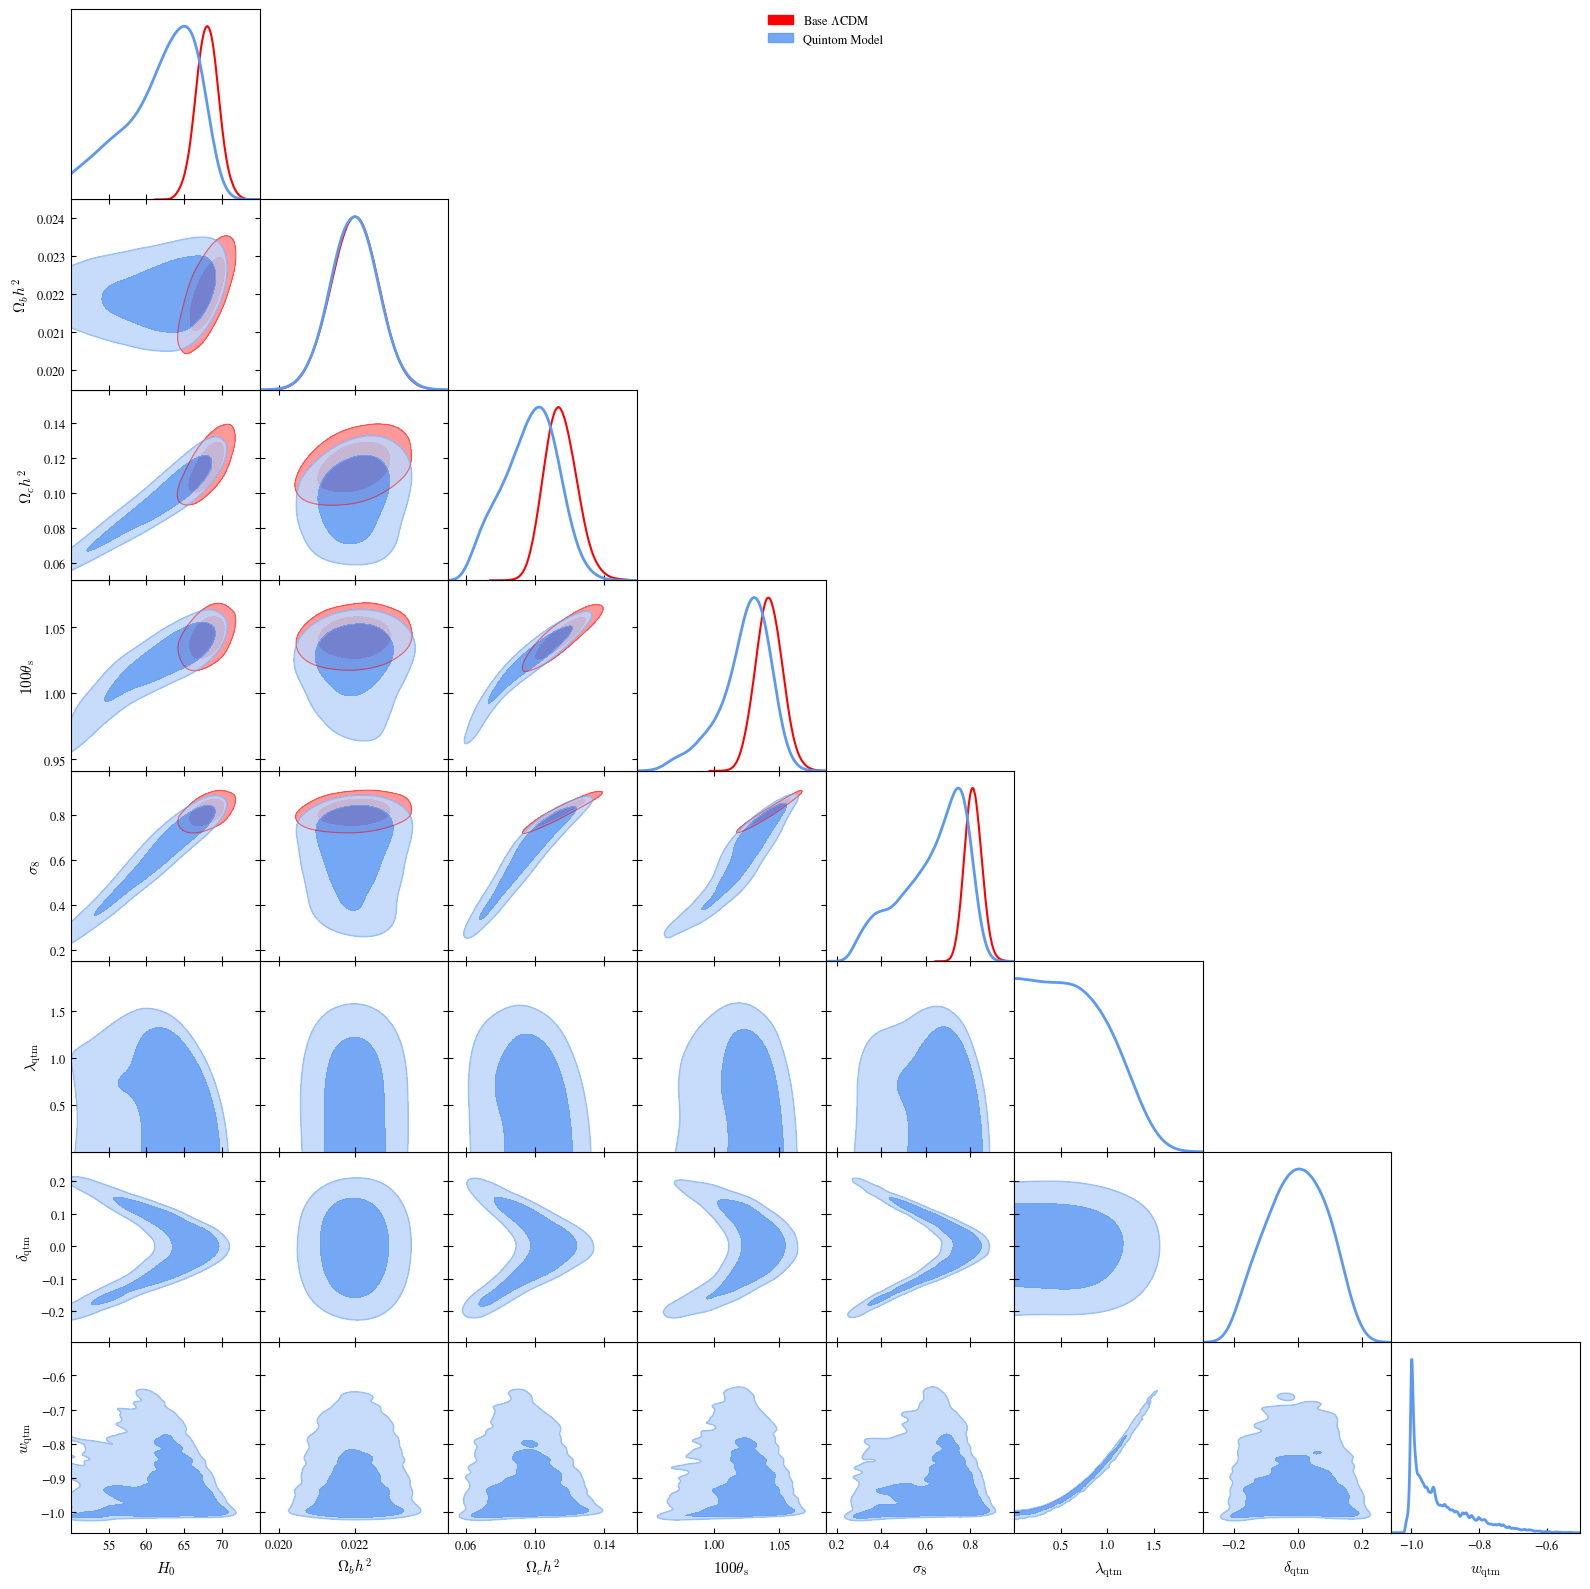

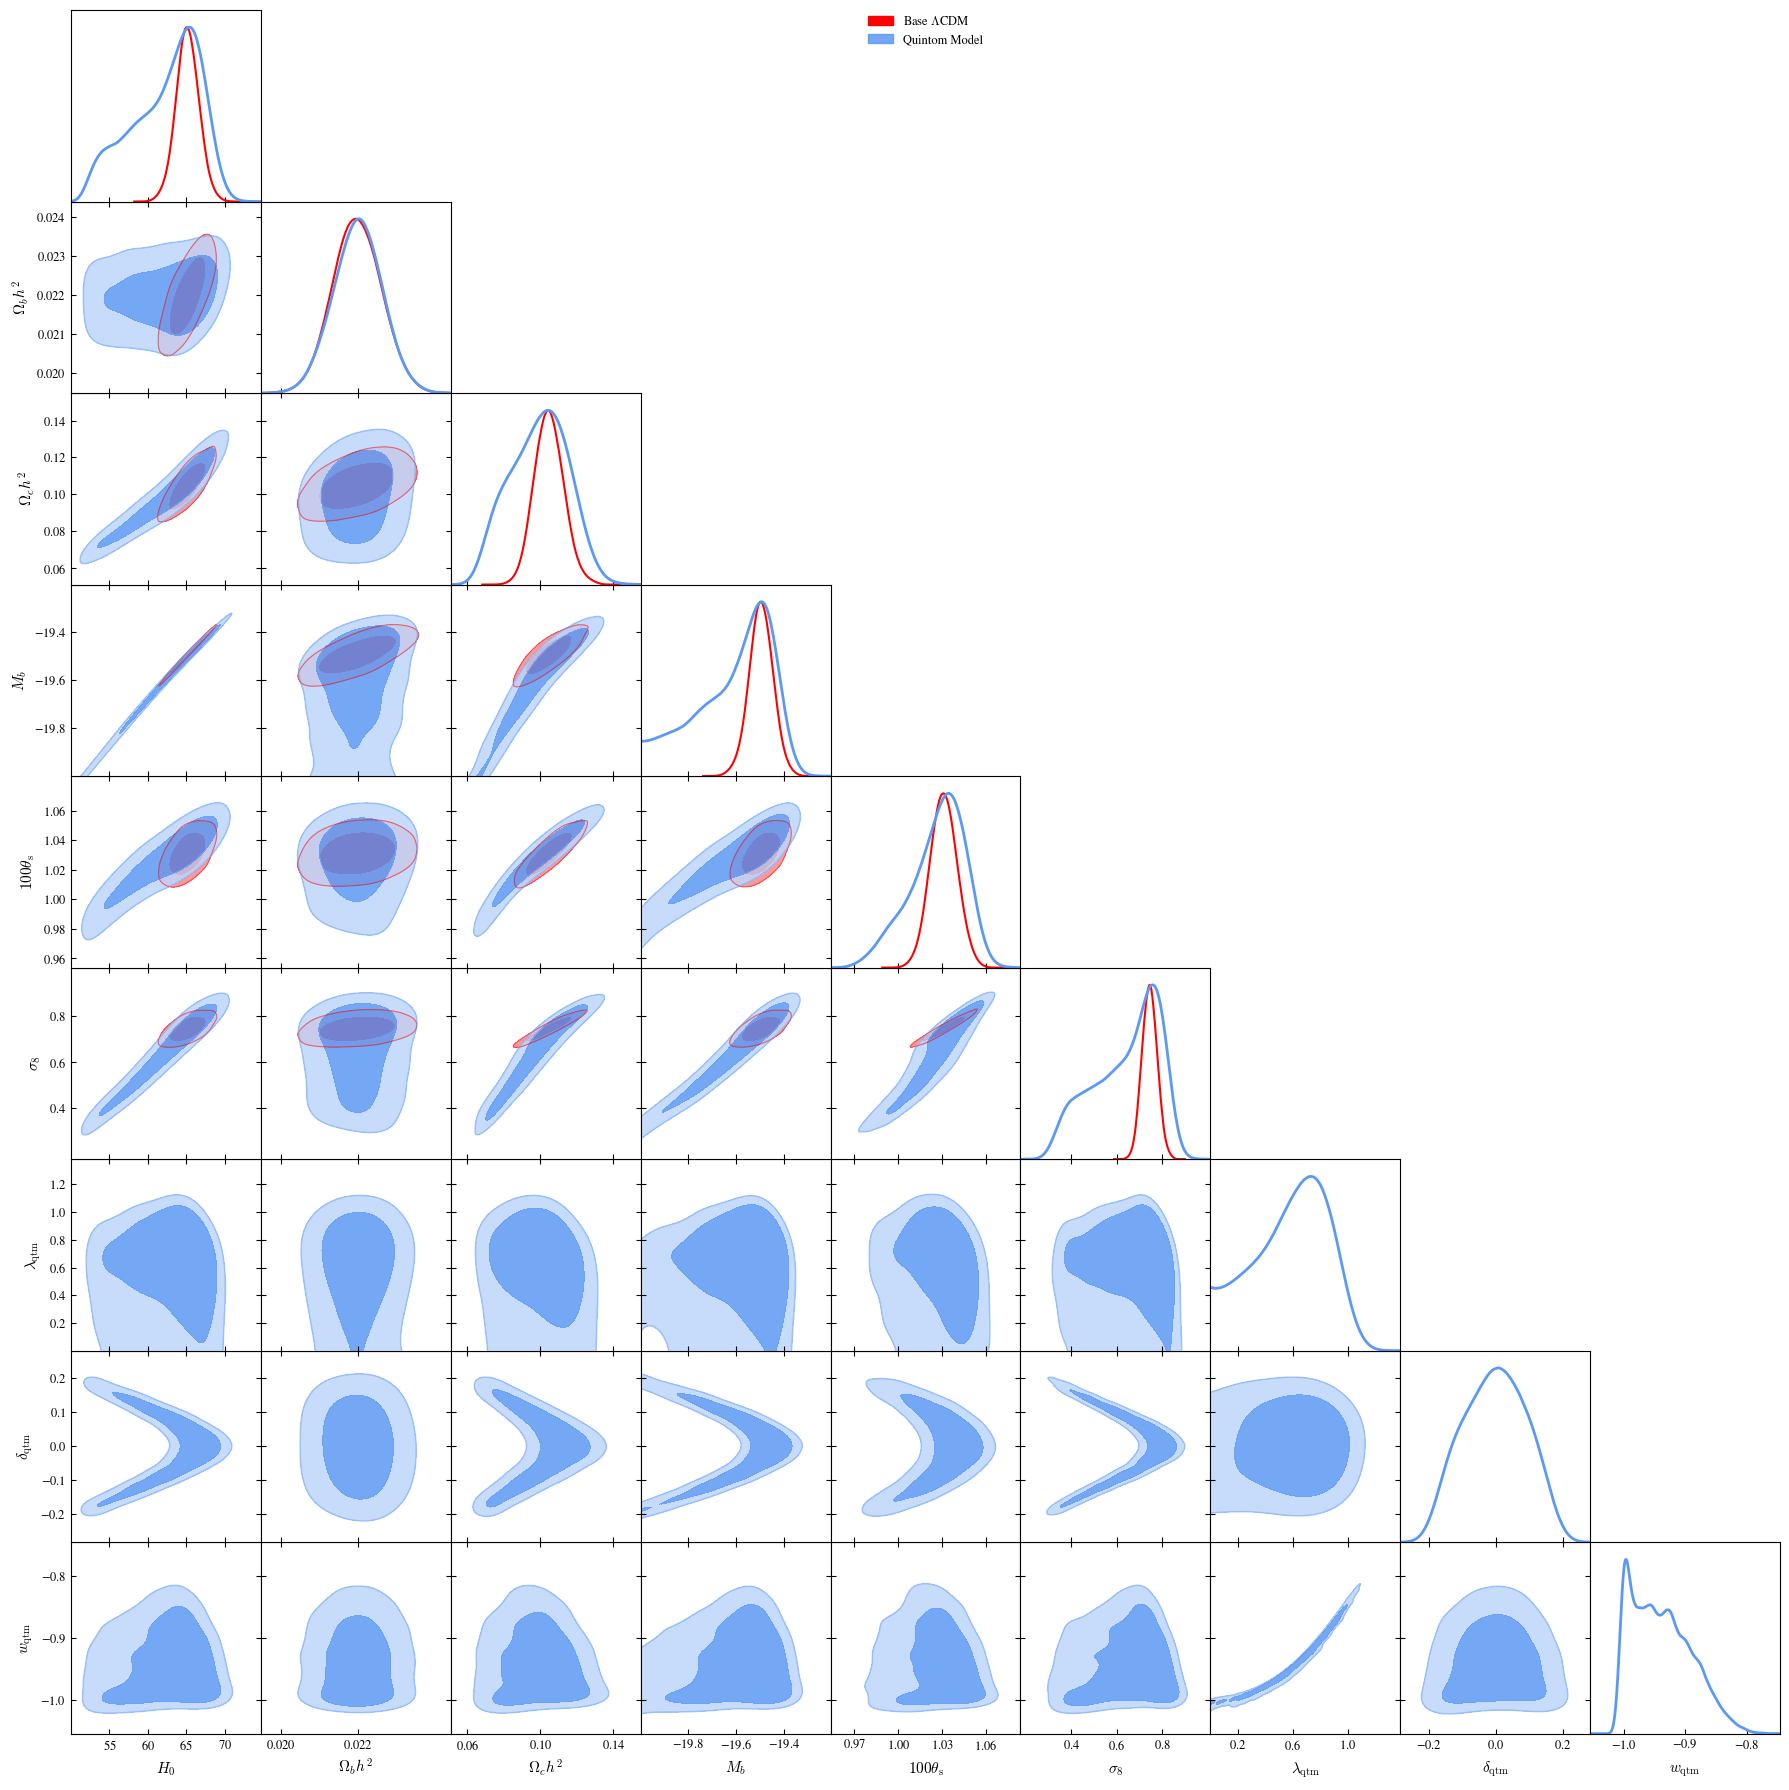

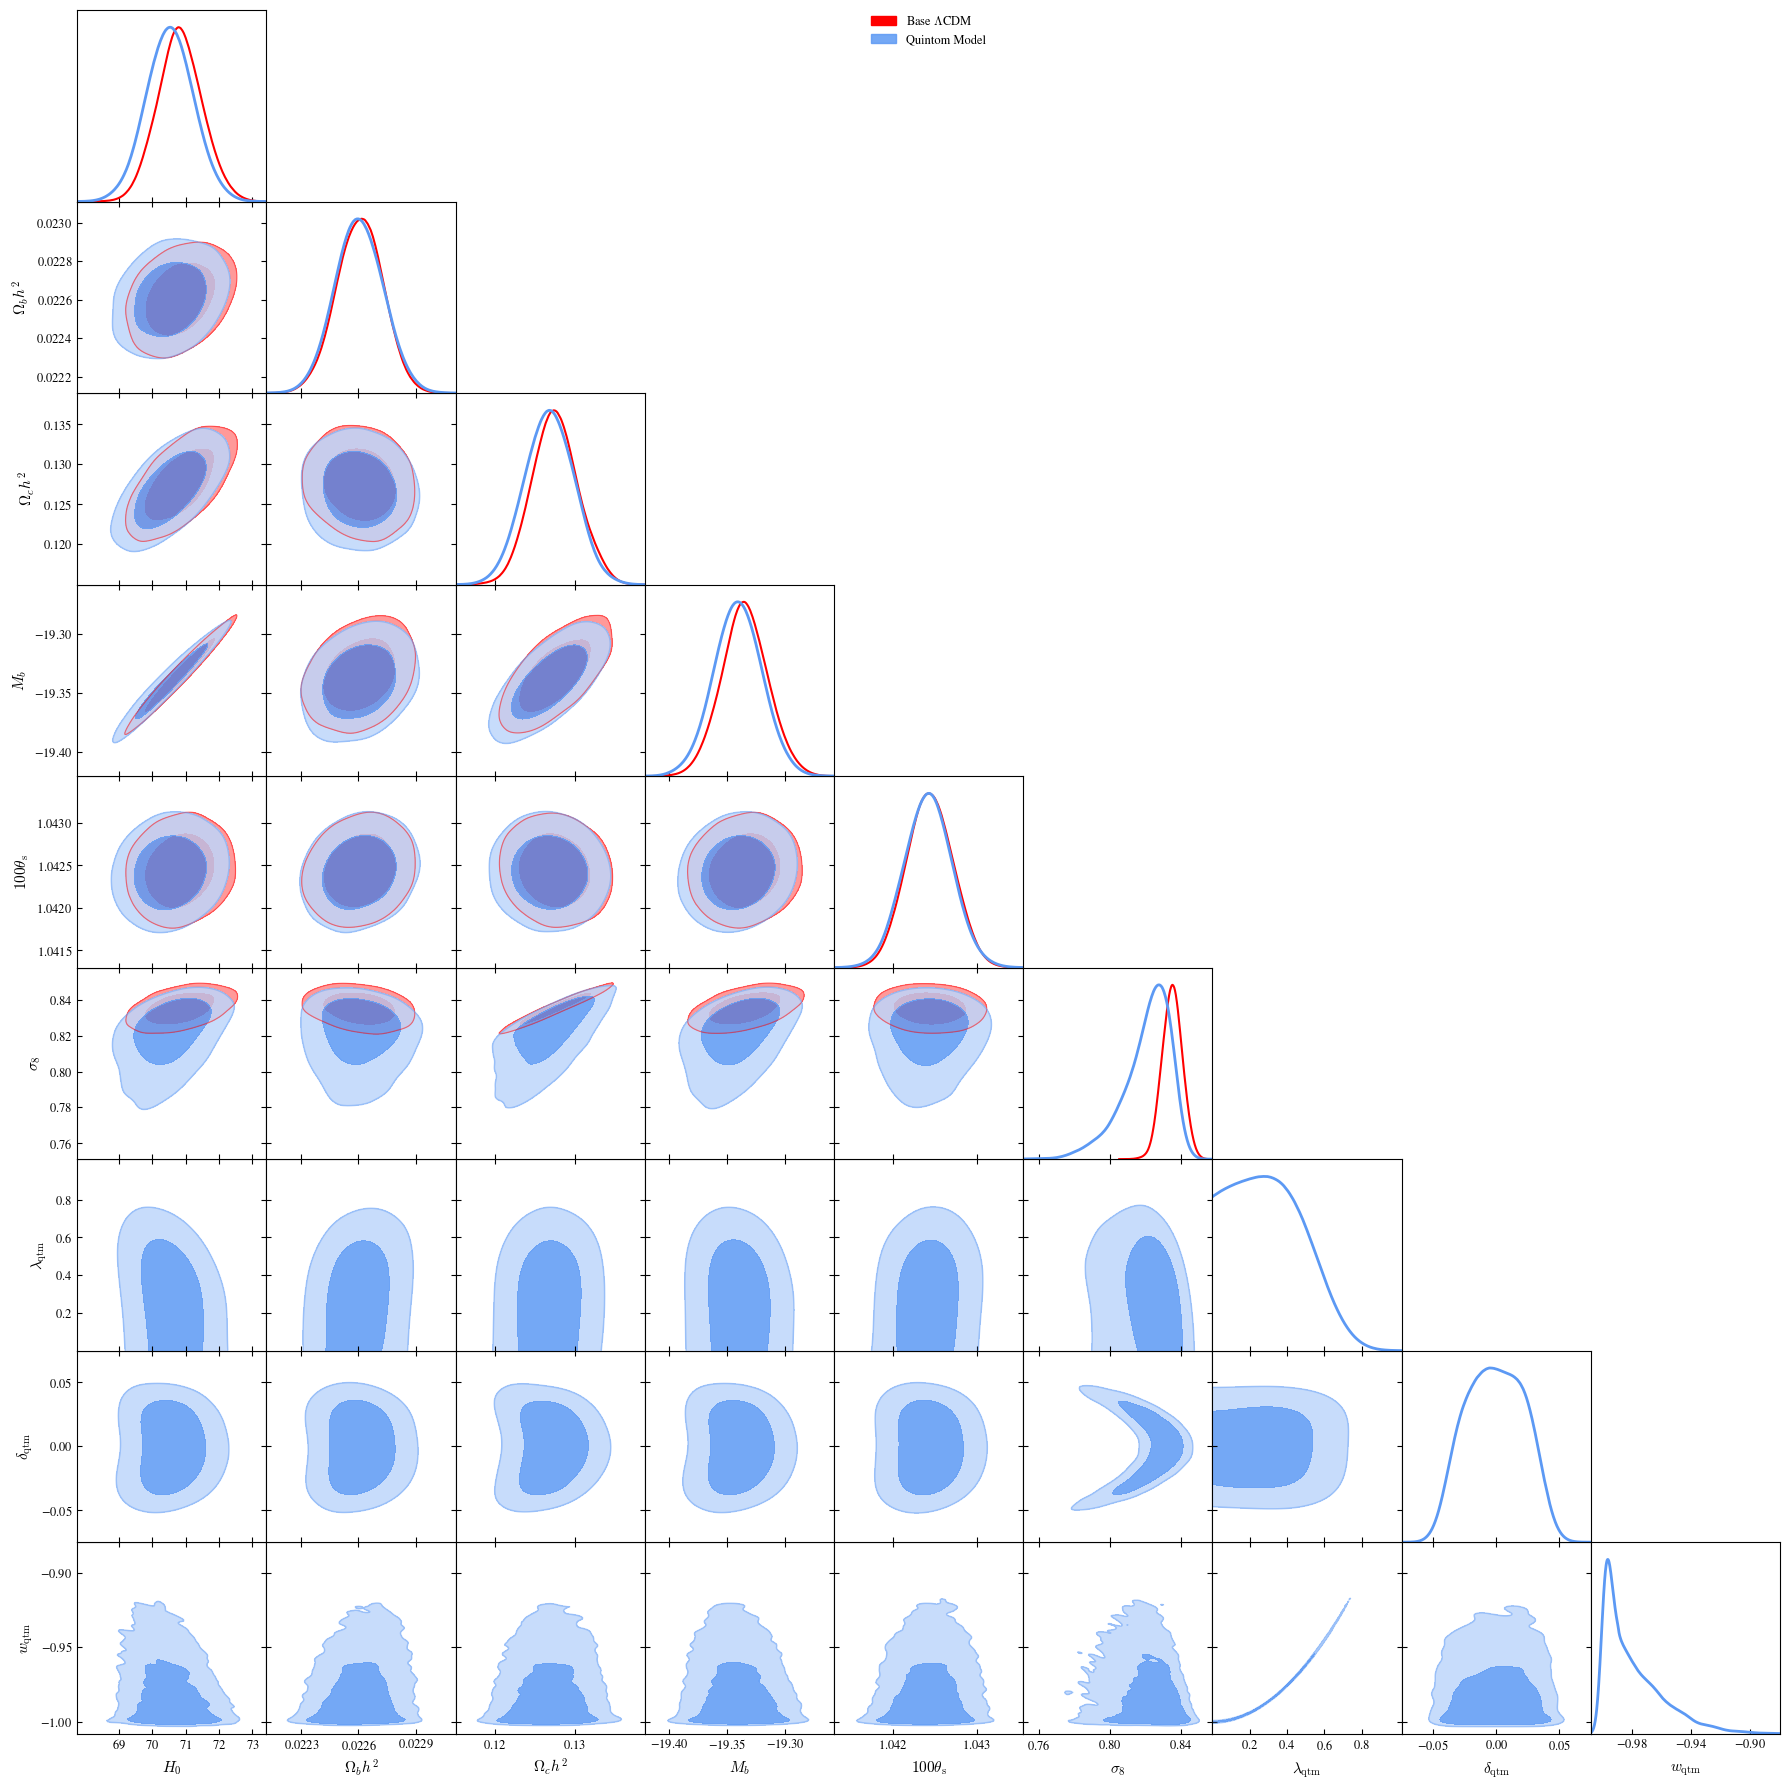

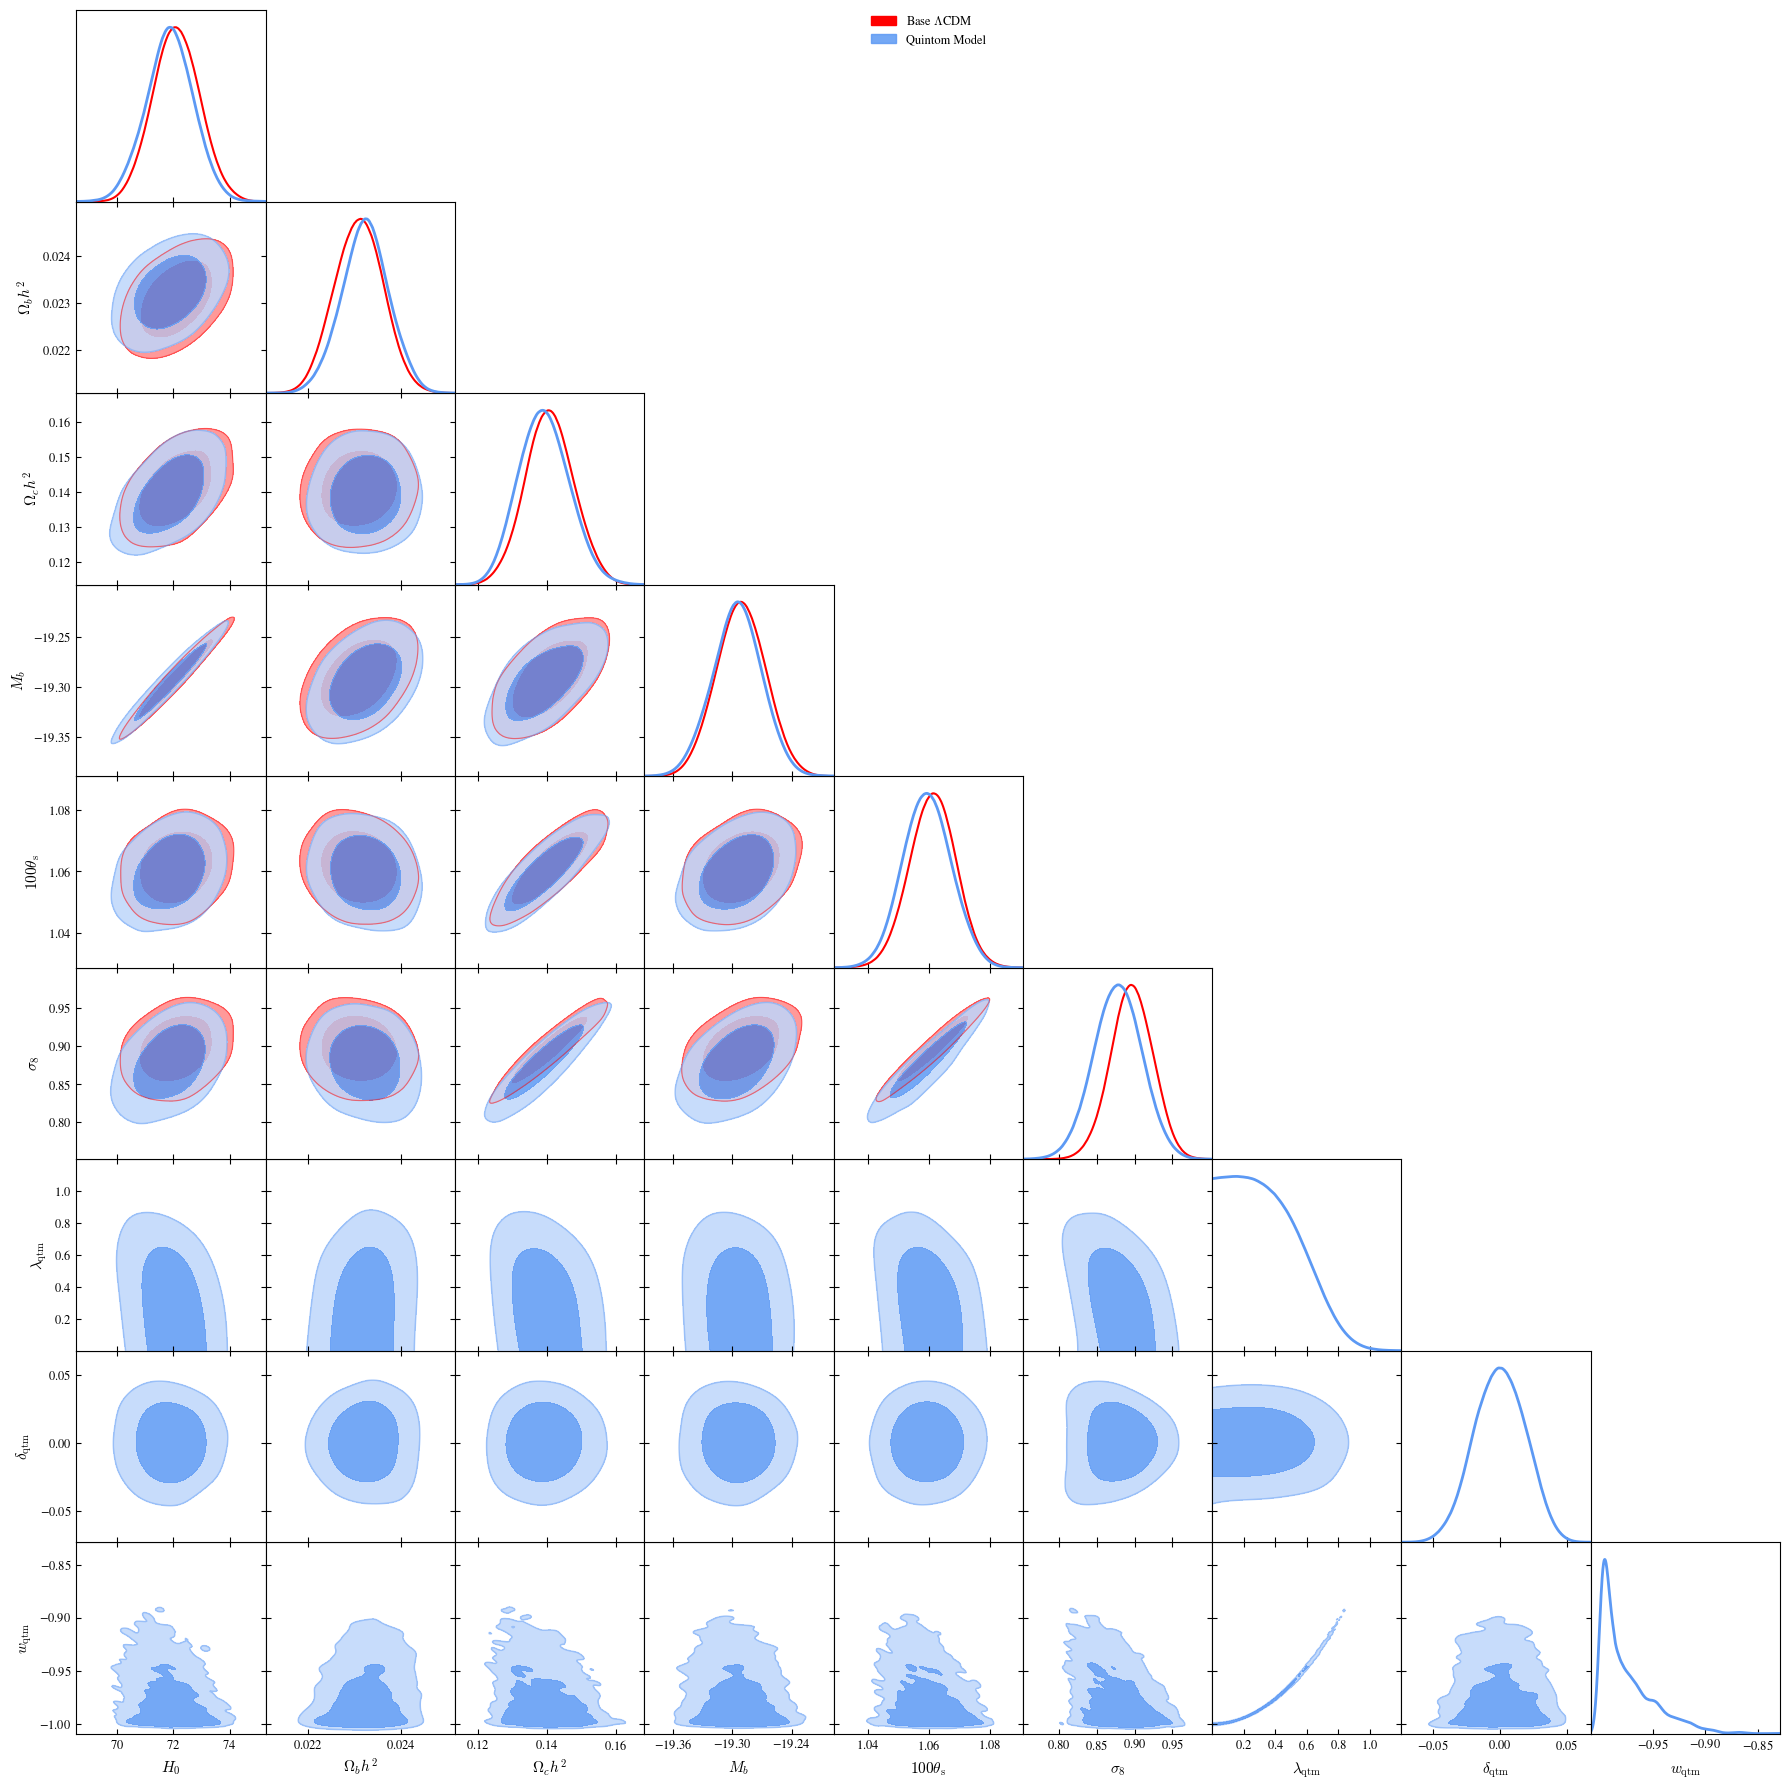

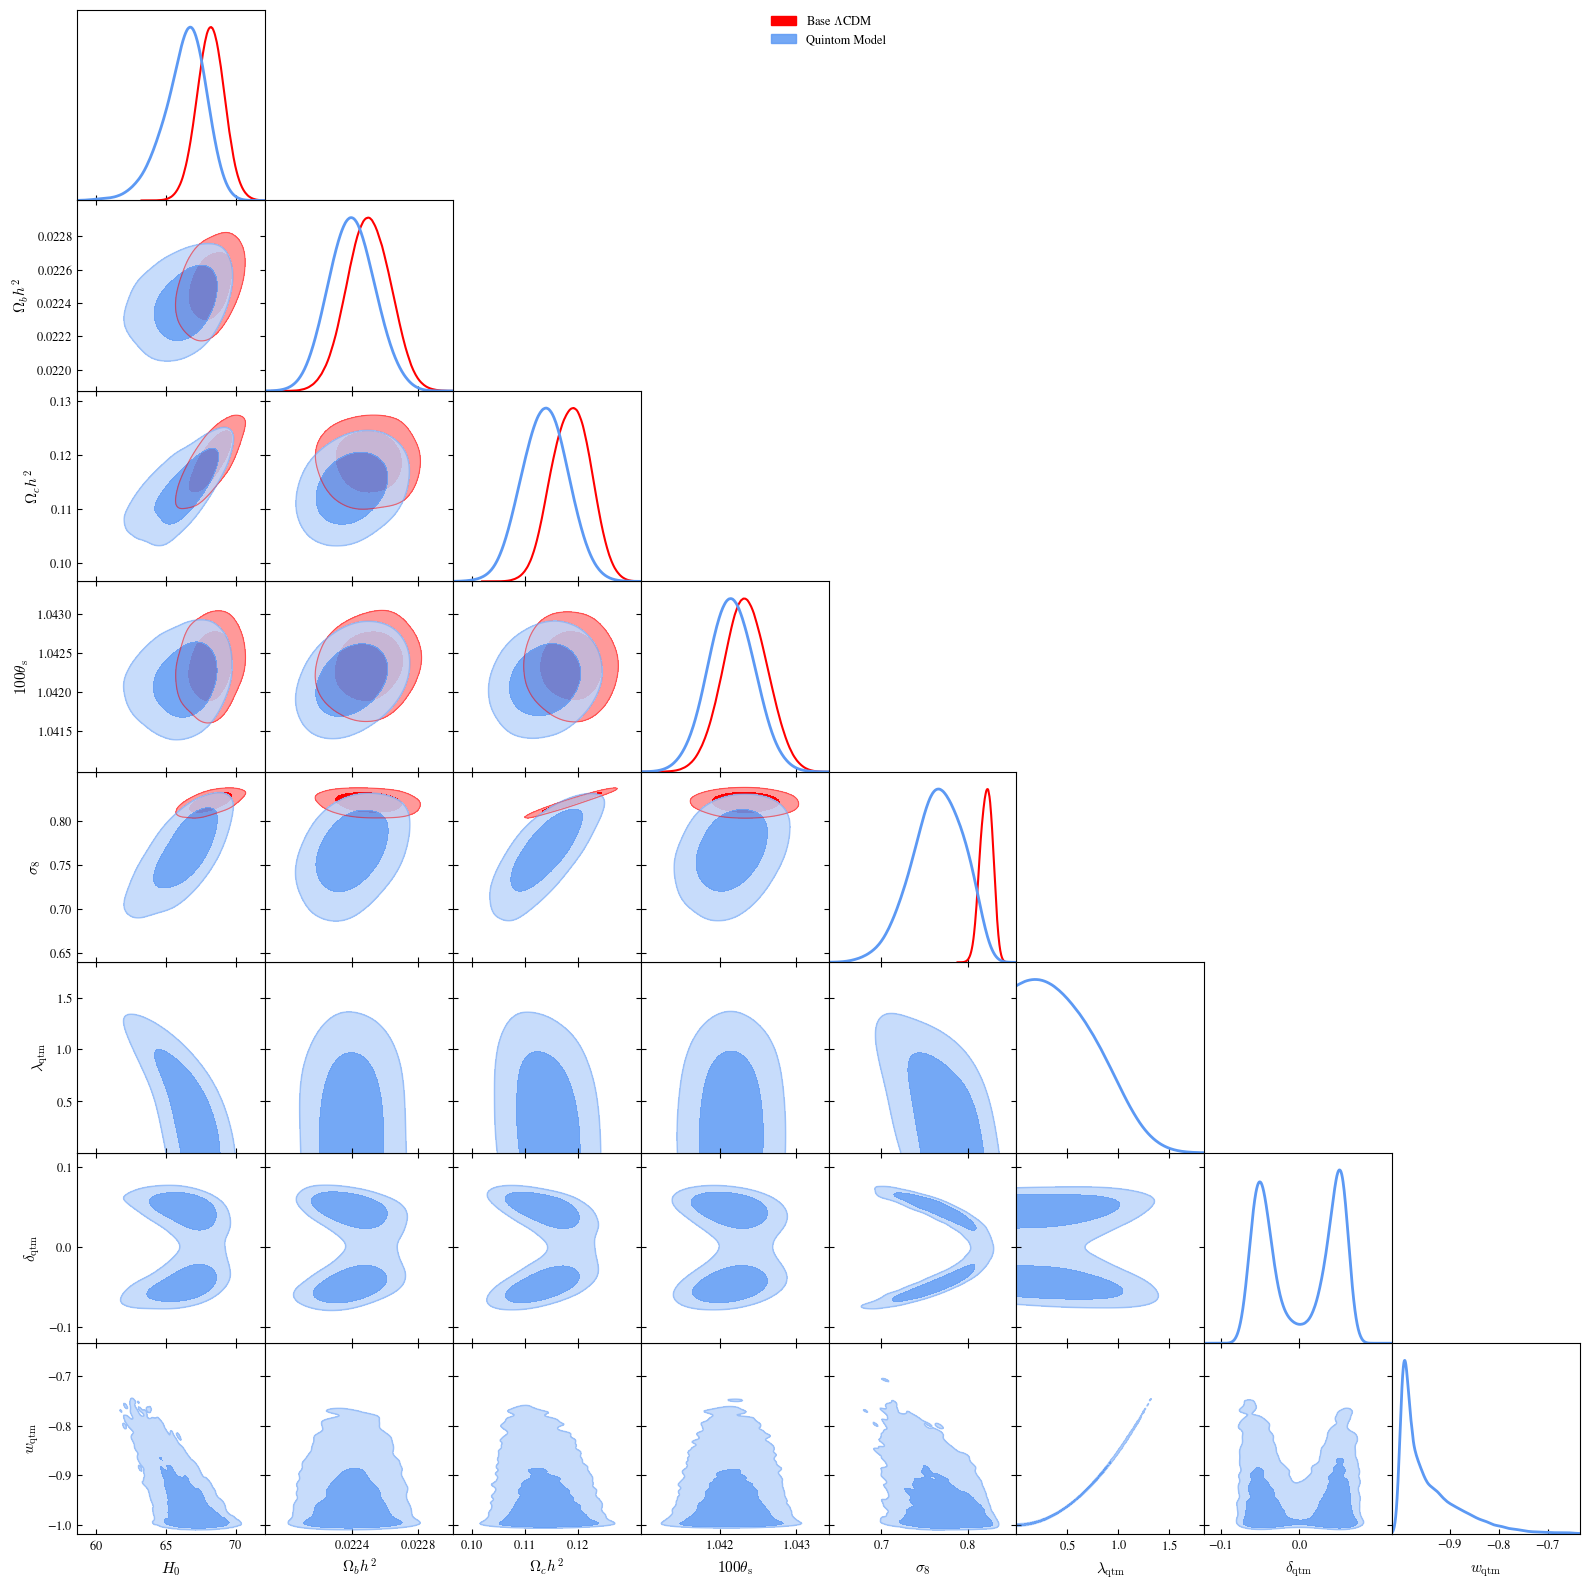

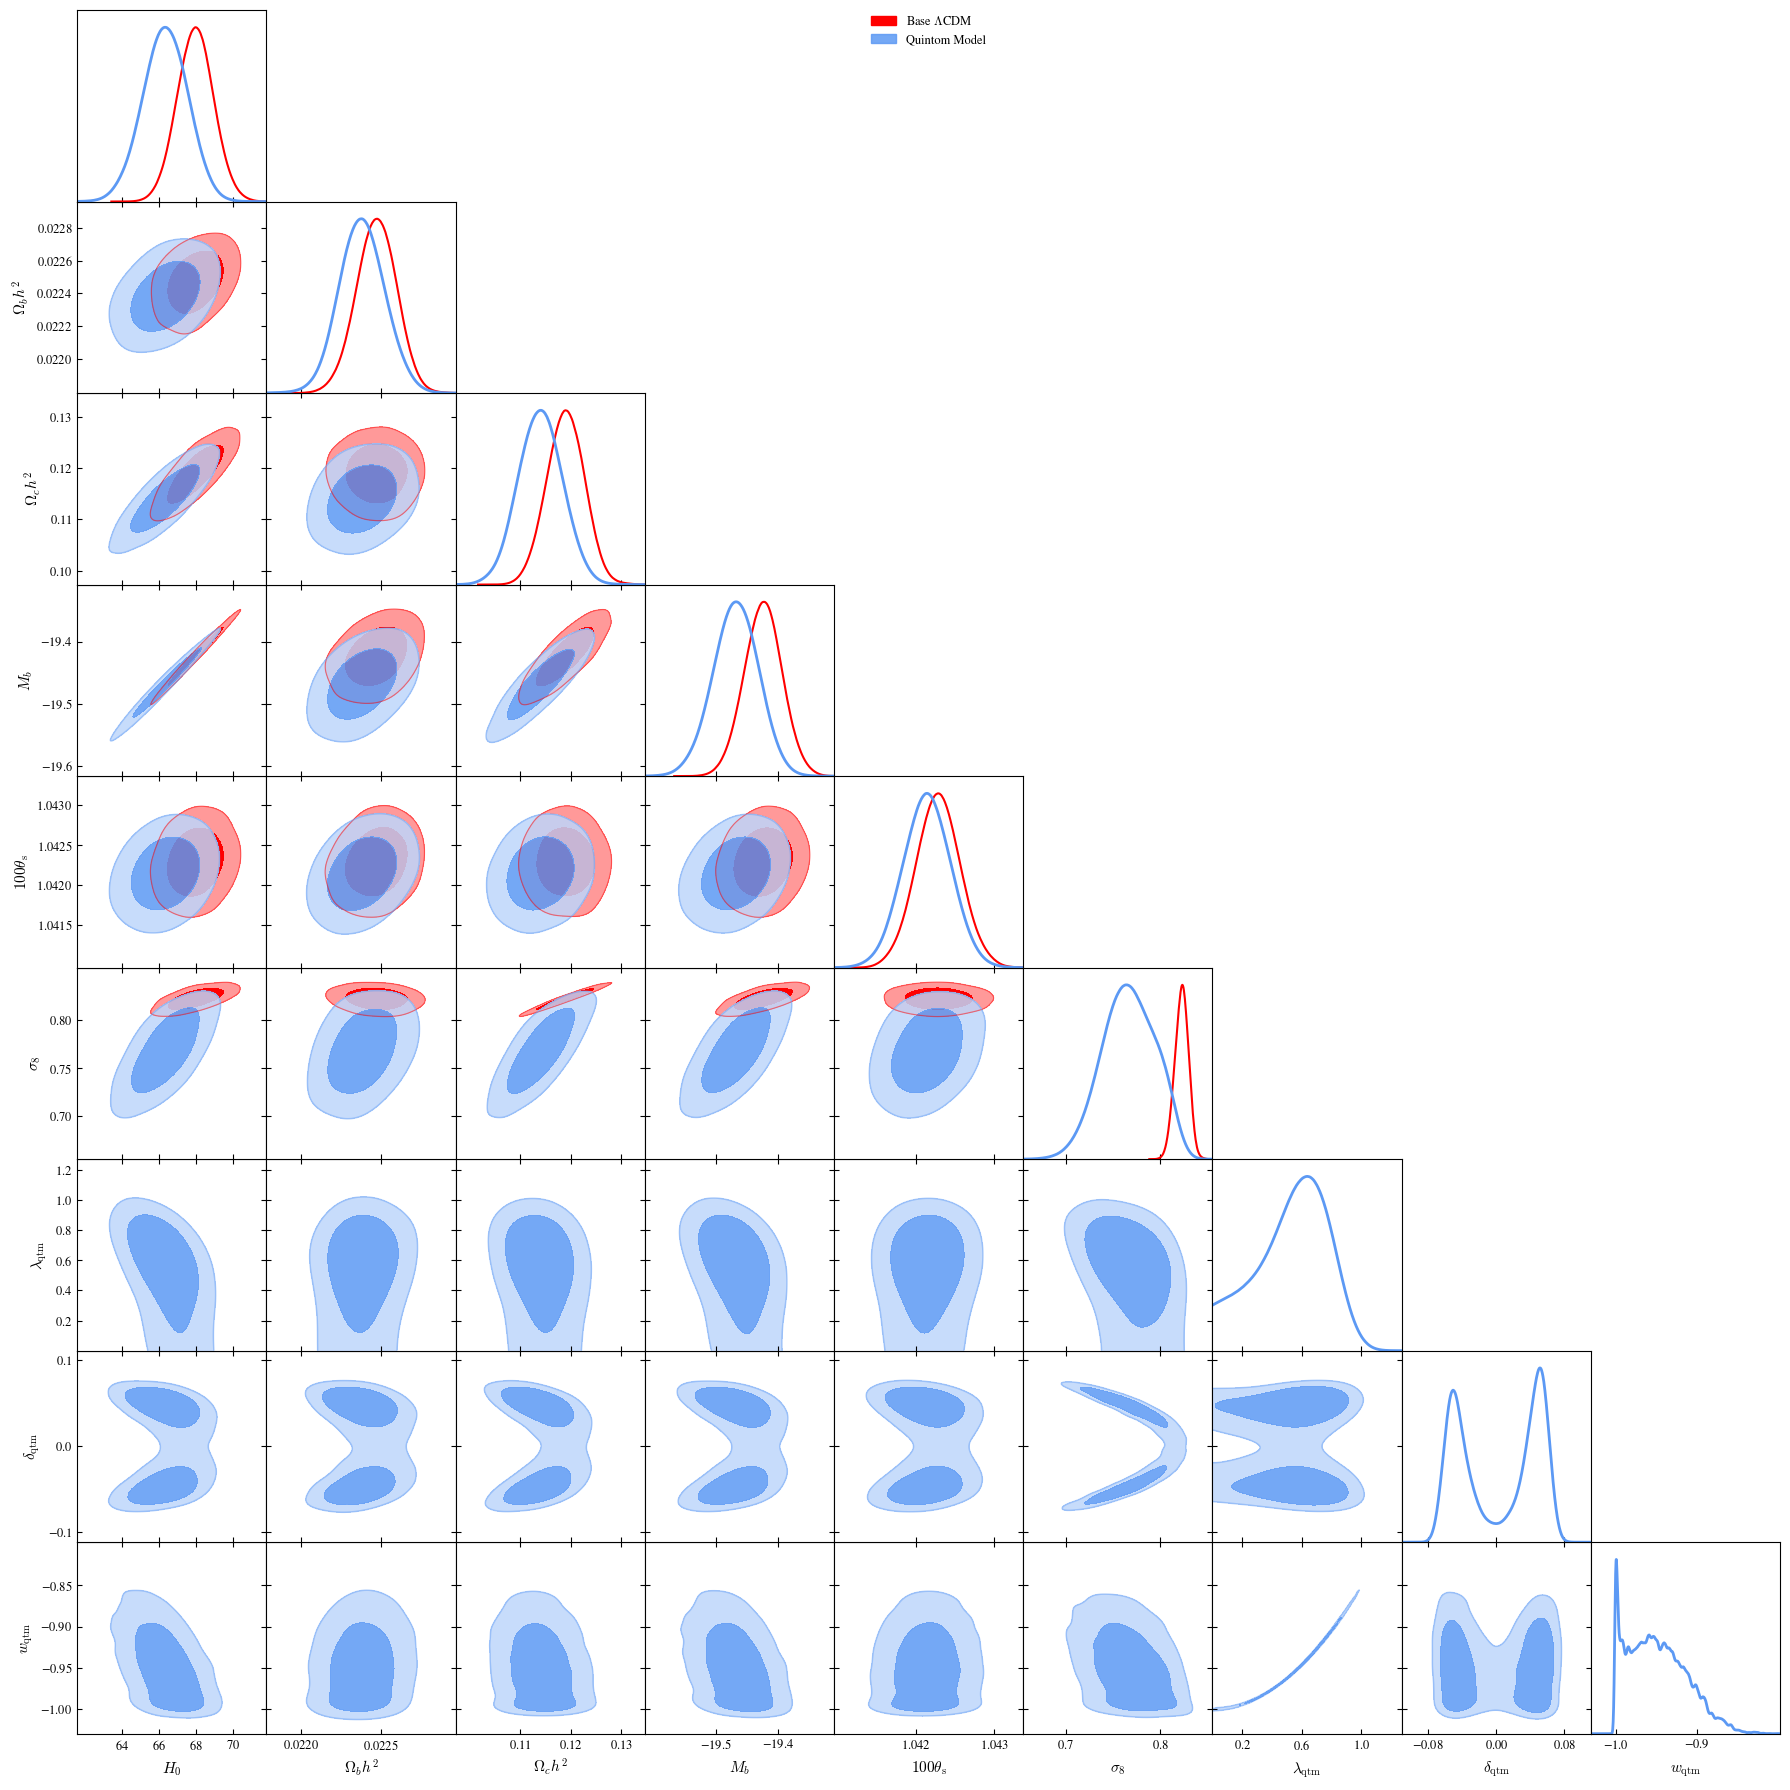

In [19]:
# Create a list of unique datasets by stripping the "Lcdm_" prefix
unique_datasets = [key.replace("Lcdm_", "") for key in models.keys() if key.startswith("Lcdm_")]

# Automatically generate a PDF for every combination
for dataset in unique_datasets:
    plot_model_comparison(dataset)

### 1D Marginalized Posteriors of $H_0$

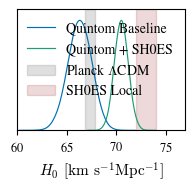

In [4]:
g = plots.get_subplot_plotter(settings=plot_settings)
g.plot_1d([models["quintom_DESI+BBN+CMB_Dist+SNIa"], 
           models["quintom_DESI+BBN+CMB_Dist+SNIa+SH0ES"]],
           'H0',
           colors=['#0072B2', '#1b9e77'])
# Grab the active axes object to overlay the external baseline bands
ax = g.subplots[0, 0]

# Add Planck Band
ax.axvspan(67.4 - 0.5, 67.4 + 0.5, color='gray', alpha=0.25, label='Planck Baseline')
ax.axvspan(73.04 - 1.04, 73.04 + 1.04, color='darkred', alpha=0.15, label='SH0ES Direct')
ax.set_xlabel(r'$H_0 \text{ [km s}^{-1} \text{Mpc}^{-1}\text{]}$')
ax.set_xlim(60.0, 77)
ax.legend(['Quintom Baseline', 'Quintom + SH0ES', 'Planck $\Lambda$CDM', 'SH0ES Local'], loc='upper right', frameon=False)


### 2D Contour Plots ($H_0$ vs. $\lambda_{\rm qtm}$ and $\delta_{\rm qtm}$)

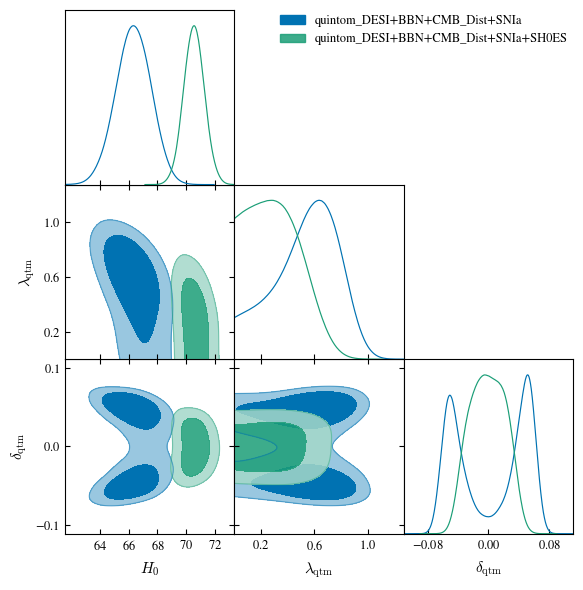

In [5]:
g.triangle_plot(
    roots=[models['quintom_DESI+BBN+CMB_Dist+SNIa'], models['quintom_DESI+BBN+CMB_Dist+SNIa+SH0ES']],
    params=['H0','lambda_qtm','delta_qtm'],
    filled=True,
    contour_colors=['#0072B2', '#1b9e77']
)

### Equation of State Reconstruction

Running CLASS 200 times... please wait.
CLASS integrations complete. Calculating statistics...


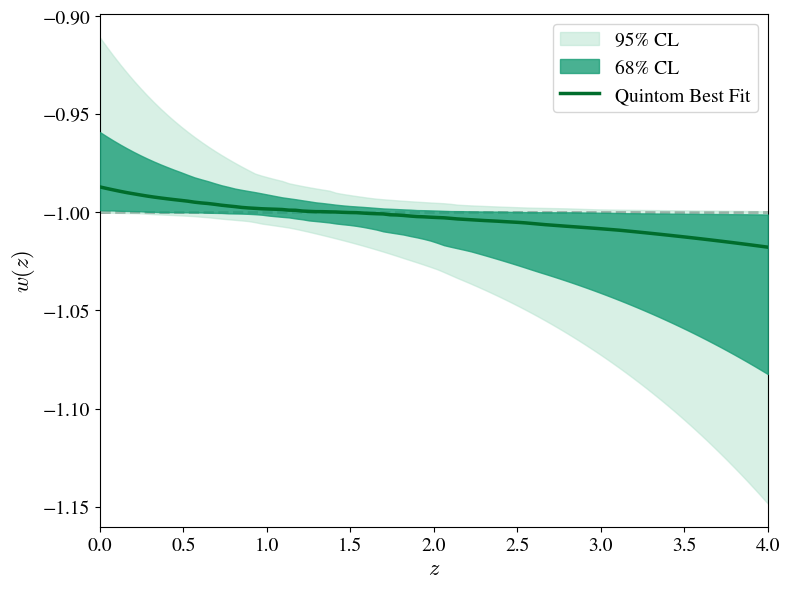

In [103]:
# ==========================================
# 1. LOAD YOUR MCMC DATA
# ==========================================
chain_path = r'/home/theppawan/class_monte/cobaya/cobaya-run/quintom_model/chains_DESI+BBN+CMB_Dist+SNIa+SH0ES/quintom_DESI+BBN+CMB_Dist+SNIa+SH0ES'
samples = loadMCSamples(chain_path, settings={'ignore_rows': 0.3})

p = samples.getParams()
weights = samples.weights

# ==========================================
# 2. STATISTICAL SUB-SAMPLING
# ==========================================
num_samples = 200 # 200 is usually plenty for a smooth, accurate plot
total_steps = len(weights)
prob_weights = weights / np.sum(weights)

# Randomly select 200 indices based on their MCMC probability
# This ensures high-probability regions get sampled more often
np.random.seed(42) # For reproducibility
selected_indices = np.random.choice(total_steps, size=num_samples, p=prob_weights)

# ==========================================
# 3. RUN CLASS FOR EACH SAMPLE
# ==========================================
z_array = np.linspace(0.0, 4.0, 100)
w_history = np.zeros((num_samples, len(z_array)))

# Initialize the CLASS wrapper
cosmo = Class()

print(f"Running CLASS {num_samples} times... please wait.")

for idx, chain_idx in enumerate(selected_indices):
    
    # Pass the exact parameters from this specific MCMC step
    # We must include H0, omega_b, and omega_cdm because background 
    # densities affect the timing of the scalar field evolution!
    class_params = {
        'output': '',          # We only need background
        'Omega_qtm': -1,
        'Omega_Lambda': 0,
        'Omega_fld': 0,
        'coupled_baryon_qtm': 'yes',
        'coupled_cdm_qtm': 'yes',
        'H0': p.H0[chain_idx],
        'omega_b': p.omega_b[chain_idx],
        'omega_cdm': p.omega_cdm[chain_idx],
        'lambda_qtm': p.lambda_qtm[chain_idx],
        'delta_qtm': p.delta_qtm[chain_idx]
    }
    
    # Execute CLASS
    cosmo.set(class_params)
    cosmo.compute()
    
    # Extract the background table
    bg = cosmo.get_background()
    z_bg = bg['z']
    
    # >>> CRITICAL STEP: Extract your specific dark energy equation of state.
    # Depending on how you coded 'class_qtm', this column might be called 
    # '(.)w_qtm', '(.)w_fld', or you might have to calculate it from pressure and density.
    # Example: w_bg = bg['(.)p_qtm'] / bg['(.)rho_qtm']
    # Update the key below to match your exact CLASS background output!
    w_bg = bg['(.)p_qtm'] / bg['(.)rho_qtm']
    
    # CLASS outputs z dynamically (more steps where physics changes fast).
    # We must interpolate it onto our fixed z_array. 
    # np.interp requires the x-axis (z) to be in increasing order, so we reverse it [::-1]
    w_history[idx, :] = np.interp(z_array, z_bg[::-1], w_bg[::-1])
    
    # Clean up memory to prevent memory leaks in the loop
    cosmo.struct_cleanup()
    cosmo.empty()

print("CLASS integrations complete. Calculating statistics...")

# ==========================================
# 4. CALCULATE CONTINUOUS ENVELOPE
# ==========================================
w_median = np.zeros(len(z_array))
w_68_lower = np.zeros(len(z_array))
w_68_upper = np.zeros(len(z_array))
w_95_lower = np.zeros(len(z_array))
w_95_upper = np.zeros(len(z_array))

for i in range(len(z_array)):
    # Since we already sub-sampled based on weights, we can just use standard percentiles
    w_95_lower[i], w_68_lower[i], w_median[i], w_68_upper[i], w_95_upper[i] = np.percentile(w_history[:, i], [2.5, 16.0, 50.0, 84.0, 97.5])

# ==========================================
# 5. DRAW THE PUBLICATION PLOT
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.axhline(-1.0, color='gray', linestyle='--', linewidth=2, zorder=1)

ax.fill_between(z_array, w_95_lower, w_95_upper, color='#b3e2cd', alpha=0.5, label='95% CL', zorder=2)
ax.fill_between(z_array, w_68_lower, w_68_upper, color='#1b9e77', alpha=0.8, label='68% CL', zorder=3)
ax.plot(z_array, w_median, color='#006d2c', linewidth=2.5, label='Quintom Best Fit', zorder=4)

ax.set_xlim(0.0, 4.0)
ax.set_xlabel(r'$z$', fontsize=16)
ax.set_ylabel(r'$w(z)$', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=14, loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('Quintom_CLASS_Reconstruction.pdf', dpi=300)
plt.show()

### Evolution of best-fit quintom model

In [50]:
best_fit = models['quintom_DESI+BBN+CMB_Dist+SNIa+SH0ES'].getParamBestFitDict(best_sample=True)
cosmo = Class()

best_fit_params = {
    'output': '',          # We only need background
    'Omega_qtm': -1,
    'Omega_Lambda': 0,
    'Omega_fld': 0,
    'coupled_baryon_qtm': 'yes',
    'coupled_cdm_qtm': 'yes',
    'H0': best_fit['H0'],
    'omega_b': best_fit['omega_b'],
    'omega_cdm': best_fit['omega_cdm'],
    'lambda_qtm': best_fit['lambda_qtm'],
    'delta_qtm': best_fit['delta_qtm']
}
cosmo.set(best_fit_params)
cosmo.compute()
bg_best_fit = cosmo.get_background()

cosmo.struct_cleanup()
cosmo.empty()

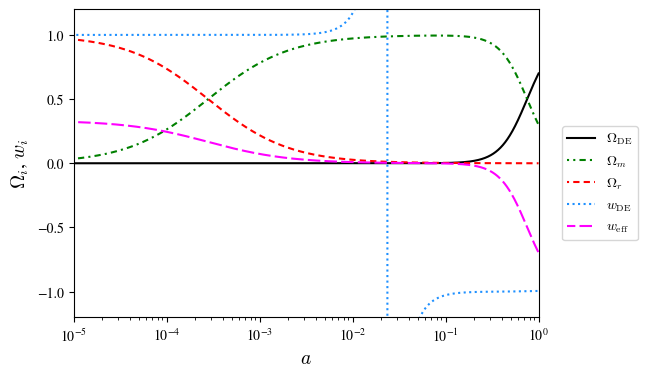

In [95]:
# quintom model
z = bg_best_fit['z']
a = 1/(1.+z)
omega_qtm = bg_best_fit['(.)rho_qtm'] / bg_best_fit['(.)rho_tot']
omega_cdm_qtm = bg_best_fit['(.)rho_cdm'] / bg_best_fit['(.)rho_tot']
omega_b_qtm = bg_best_fit['(.)rho_b'] / bg_best_fit['(.)rho_tot']
omega_m_qtm = omega_cdm_qtm + omega_b_qtm
omega_r_qtm = (bg_best_fit['(.)rho_g'] + bg_best_fit['(.)rho_ur']) / bg_best_fit['(.)rho_tot']
w_qtm = bg_best_fit['(.)p_qtm']/bg_best_fit['(.)rho_qtm']
w_eff = bg_best_fit['(.)p_tot']/bg_best_fit['(.)rho_tot']

qty_list = [omega_qtm, omega_m_qtm, omega_r_qtm, w_qtm, w_eff]
label_list = [r'$\Omega_\text{DE}$', r'$\Omega_{m}$', r'$\Omega_r$', r'$w_\text{DE}$', r'$w_\text{eff}$']
color_list = ['k', 'green', 'red', 'dodgerblue', 'magenta']
lsty_list = ['-', (2,(3,2,1,2)), (2, (3, 2)), ':', (2, (6, 2))]

fig, ax = plt.subplots(figsize=(6,4))
qtm_lines = {}
for k in range(len(qty_list)):
    qtm_lines[k], = ax.semilogx(a, qty_list[k], color=color_list[k], linestyle=lsty_list[k])

omegas = [qtm_lines[k] for k in range(len(qty_list))]
ax.legend(omegas, [label_list[k] for k in range(5)], loc=(1.05,0.25))
plt.xlabel(r'$a$', fontsize=14)
plt.ylabel(r'$\Omega_i$, $w_i$', fontsize=14)
plt.xlim(1e-5, 1)
plt.ylim(-1.2, 1.2)
plt.show()

### Summary of Cosmological Parameters Constraints of All Combined Observational data

In [20]:
def generate_latex_tables(params=None, limit=1):

    table_latex = "\\begin{table*}\n"
    table_latex += "\\centering\n"
    table_latex += "\\resizebox{\linewidth}{!}{\n"
    if params is None:
        params = ['H0','Omega_m','sigma8', 'lambda_qtm','delta_qtm']
    table_latex += "\\begin{tabular}{l"+ "c"*len(params) +"}\n"
    table_latex += "\\toprule\n"

    # Title
    table_latex += "Model/Dataset "
    for label in params:
        table_latex += f"& {label} "
    table_latex += "\\\\\n"

    # Data Result
    table_latex += "\\midrule\n"
    for theory in extract_model.keys():
        table_latex += theory + " & "*len(params) + "\\\\ \n"
        for dataset in extract_model[theory]:
            table_latex += dataset.replace("_","\\_")
            for param in params:
                try:
                    table_latex += " & " + "$" + models[f'{theory}_{dataset}'].getInlineLatex(param, limit=1).replace(">","=>").replace("<","=<").split("=", 1)[1]+ "$"
                except:
                    table_latex += " & --- "
            table_latex += " \\\\ \n"
        table_latex += "\\hline\n"
    table_latex += "\\end{tabular}\n"
    table_latex += "}\n"
    table_latex += "\\caption{write the caption}\n"
    table_latex += "\\label{tab:cosmo_constraints}\n"
    table_latex += "\\end{table*}"    

    print(table_latex)

In [21]:
generate_latex_tables()

\begin{table*}
\centering
\resizebox{\linewidth}{!}{
\begin{tabular}{lccccc}
\toprule
Model/Dataset & H0 & Omega_m & sigma8 & lambda_qtm & delta_qtm \\
\midrule
Lcdm &  &  &  &  & \\ 
DESI+BBN & $ 68.1\pm 1.5$ & $ 0.295^{+0.014}_{-0.016}$ & $ 0.812\pm 0.039$ & ---  & ---  \\ 
DESI+BBN+SNIa & $ 65.2\pm 1.5$ & $ 0.298\pm 0.012$ & $ 0.745\pm 0.034$ & ---  & ---  \\ 
CMB\_Dist & ---  & ---  & ---  & ---  & ---  \\ 
DESI+BBN+CMB\_Dist+SNIa+SH0ES & $ 70.83\pm 0.67$ & $ 0.2993\pm 0.0049$ & $ 0.8353\pm 0.0057$ & ---  & ---  \\ 
CMBprior & ---  & ---  & ---  & ---  & ---  \\ 
DESI+BBN+SNIa+SH0ES & $ 72.11\pm 0.83$ & $ 0.315\pm 0.012$ & $ 0.896\pm 0.028$ & ---  & ---  \\ 
DESI+BBN+CMB\_Dist & $ 68.22\pm 0.99$ & $ 0.3036\pm 0.0056$ & $ 0.8213\pm 0.0072$ & ---  & ---  \\ 
DESI+BBN+CMB\_Dist+SNIa & $ 67.96\pm 0.99$ & $ 0.3063\pm 0.0054$ & $ 0.8224^{+0.0076}_{-0.0069}$ & ---  & ---  \\ 
SNIa & $ 69^{+10}_{-7}$ & $ 0.330\pm 0.018$ & $ 0.91^{+0.25}_{-0.15}$ & ---  & ---  \\ 
\hline
quintom &  &  &  & 